In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
ls binaural_eval/precedence_distractor_test/

word_task_20p_loc_v07_wider_SNR/
word_task_half_co_loc_v06/
word_task_half_co_loc_v07/
word_task_half_co_loc_v07_gend_bal/
word_task_half_co_loc_v08_gender_bal_4M_orig/
word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/
word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/
word_task_standard_v07/
word_task_standard_v07_more_tests/
word_task_standard_v07_old_ckpt/
word_task_v09_control_no_attn/


In [41]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations
# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/precedence_distractor_test_v02/").glob("*/*.pkl"))
# output_paths = list(Path(f"ls /om2/user/rphess/Auditory-Attention/binaural_eval/precedence_distractor_test/").glob("*/*.pkl"))

stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')

remap_azim = lambda azim: 360 - azim if azim > 90 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'diff'}

for path in output_paths:
    if 'v09' not in path.stem:
        continue
    # if any([string in path.stem for string in ['v06', 'more', 'old']]):
    #     continue
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem
    # merge with stim manifest
    df = df.join(stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')  
    diotic =  True if 'diotic' in path.stem else False 
    df['diotic'] = diotic
    df['diotic_cond'] = None
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    if diotic:
        target_loc = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')[0]
        df["target_azim"], df["target_elev"] = target_loc, target_loc
        distractor_loc = path.stem.split('_distract_loc_')[1].split('_')[0] 
        df["distractor_azim"], df["distractor_elev"] = distractor_loc, distractor_loc
        if snr == 'clean':
            df['diotic_cond'] = 'clean'
        else:
            df['diotic_cond'] = 'overlap' if target_loc == distractor_loc else distractor_loc
        df['dist_lead_channel'] = distractor_loc

    else:
        df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
        df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
        # map azim to 0-180
        df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
        df['target_elev'] = df['target_elev'].astype(int)
        df['distractor_elev'] = df['distractor_elev'].astype(int)
        lead_channel = path.stem.split('_lead_')[0].split('_')[-1]
        if lead_channel == 'None':
            if (df['target_azim'].values == df['distractor_azim'].values).all():
                lead_channel = 'F-F'
            elif (df['target_azim'].values != df['distractor_azim'].values).all():
                lead_channel = 'F-R'
        else:
            if 'target_lead' in path.stem:
                # print('both simulated')
                if lead_channel == 'center':
                    lead_channel = 'FR-FR'
                elif lead_channel == 'side':
                    lead_channel = 'FR-RF'
            else:
                if lead_channel == 'center':
                    lead_channel = 'F-FR'
                elif lead_channel == 'side':
                    lead_channel = 'F-RF'
    
        df['dist_lead_channel'] = lead_channel

        
    df['gender_cond'] = df["gender"].values == df['bg_gender'].values
    df['gender_cond'] =  df['gender_cond'].map(gend_map)
    if 'clean' in path.stem:
        df['snr'] = 'clean'
    else:
        df['snr'] = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    
    results_dfs.append(df)
results = pd.concat(results_dfs)

In [42]:
results.loc[(results.distractor_azim != 0) & (results.dist_lead_channel == "F-F")] = results[results.dist_lead_channel == "F-F"] 

In [43]:
results[results.model == 'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout']

,accuracy,confusions,preds,true_word_int,model,word,bg_word,gender,bg_gender,diotic,diotic_cond,snr,target_azim,target_elev,distractor_azim,distractor_elev,dist_lead_channel,gender_cond
0,1,0,135,135,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,commercial,hours,male,female,False,None,-12,0,0,60,0,F-R,diff
1,1,0,618,618,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,showed,british,male,female,False,None,-12,0,0,60,0,F-R,diff
2,0,0,756,693,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,technology,within,female,female,False,None,-12,0,0,60,0,F-R,same
3,0,0,637,638,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,sound,river,female,female,False,None,-12,0,0,60,0,F-R,same
4,0,0,726,381,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,lives,minutes,female,female,False,None,-12,0,0,60,0,F-R,same
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3151,0,1,136,329,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,including,common,male,male,False,None,0,0,0,-60,0,FR-RF,same
3152,1,0,80,80,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,brother,council,male,male,False,None,0,0,0,-60,0,FR-RF,same
3153,1,0,18,18,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,airport,catholic,male,male,False,None,0,0,0,-60,0,FR-RF,same
3154,0,0,787,386,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,london,brown,male,male,False,None,0,0,0,-60,0,FR-RF,same


In [44]:
grouped_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim','dist_lead_channel', 'diotic',
                                 'distractor_elev', 'gender_cond', 'snr']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
# remove trailing underscore
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]


# # grouped_results["elevation_cond"] = grouped_results.apply(lambda row: f"target {row.target_elev} distractor {row.distractor_elev}", axis=1)
# grouped_results['elevation_sep'] = grouped_results.target_elev - grouped_results.distractor_elev
# grouped_results['abs_elevation_sep'] = grouped_results.elevation_sep.abs()
# grouped_results['elevated_source'] = grouped_results.elevation_sep.apply(lambda x: 'target' if x > 0 else 'distractor' if x < 0 else 'co-located') 

# grouped_results['abs_target_azim'] = grouped_results.target_azim.abs()
# grouped_results['abs_distractor_azim'] = grouped_results.distractor_azim.abs()

# grouped_results['azim_delta'] = grouped_results.target_azim - grouped_results.distractor_azim
# grouped_results['abs_azim_delta'] = (grouped_results.target_azim - grouped_results.distractor_azim).abs()




In [45]:
grouped_results.model.unique()

array(['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
       'word_task_v09_control_no_attn'], dtype=object)

In [46]:
grouped_results

,model,target_azim,target_elev,distractor_azim,dist_lead_channel,diotic,distractor_elev,gender_cond,snr,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem
0,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,0,0,-60,FR-FR,False,0,diff,-12,0.199620,0.010065,0.358048,0.012073
1,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,0,0,-60,FR-FR,False,0,diff,-8,0.301014,0.011551,0.265526,0.011121
2,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,0,0,-60,FR-FR,False,0,diff,-4,0.416984,0.012416,0.187579,0.009830
3,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,0,0,-60,FR-FR,False,0,diff,0,0.517744,0.012583,0.124208,0.008305
4,word_task_half_co_loc_v09_gender_bal_4M_w_no_c...,0,0,-60,FR-FR,False,0,same,-12,0.135615,0.008622,0.542459,0.012545
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,word_task_v09_control_no_attn,0,0,60,F-RF,False,0,diff,0,0.665399,0.011882,0.030418,0.004325
88,word_task_v09_control_no_attn,0,0,60,F-RF,False,0,same,-12,0.311153,0.011658,0.245881,0.010843
89,word_task_v09_control_no_attn,0,0,60,F-RF,False,0,same,-8,0.437262,0.012491,0.151458,0.009027
90,word_task_v09_control_no_attn,0,0,60,F-RF,False,0,same,-4,0.555767,0.012512,0.081115,0.006875


In [47]:
freyman_human_data = np.array([-11.937626695774213,73.05785123966942,
                            -7.8768127241540675,85.2892561983471,
                            -3.8259784812100452,92.23140495867769,
                            0.17838765008576019,94.54545454545455,
                            -11.99844066739436,40.826446280991746,
                            -7.911429907999382,66.94214876033058,
                            -3.8920941836893856,77.19008264462809,
                            0.09168875721191228,88.59504132231405,
                            -11.95696242008421,42.80991735537191,
                            -7.883050054576644,61.98347107438017,
                            -3.933884297520663,75.04132231404958,
                            0.15874005925463663,84.13223140495867,
                            -12.006237330422584,36.69421487603306,
                            -7.984406673943557,48.26446280991736,
                            -3.9828473413379104,49.0909090909091,
                            0.08794635895836223,66.61157024793388]).reshape(-1,2)

freyman_human_data = pd.DataFrame({'snr':freyman_human_data[:,0], 'accuracy':freyman_human_data[:,1]})
freyman_human_data['diotic_cond'] = ["F-R"] * 4 + ["F-RF"] * 4 + ["F-FR"] * 4 + ["F-F"] * 4
freyman_human_data

,snr,accuracy,diotic_cond
0,-11.937627,73.057851,F-R
1,-7.876813,85.289256,F-R
2,-3.825978,92.231405,F-R
3,0.178388,94.545455,F-R
4,-11.998441,40.826446,F-RF
5,-7.911430,66.942149,F-RF
6,-3.892094,77.190083,F-RF
7,0.091689,88.595041,F-RF
8,-11.956962,42.809917,F-FR
9,-7.883050,61.983471,F-FR


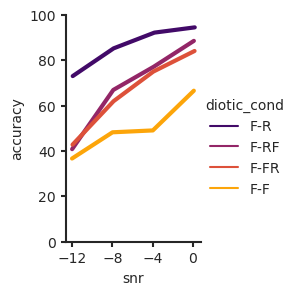

In [48]:

g = sns.relplot(data=freyman_human_data, x='snr', y='accuracy', 
            hue='diotic_cond', kind='line', palette='inferno',
            height=3, linewidth=3, aspect=0.75)
g.set(yticks=np.arange(0,  101, 20), xticks=np.arange(-12,  1, 4))
# thicken axis lines
for axis in ['bottom','left']:
    g.ax.spines[axis].set_linewidth(1.5)
# match x and y tick thickness to axes lines
g.ax.tick_params(width=1.5)

### MAKE Poster fig 

In [49]:
freyman_grouped_results = results[results.diotic == False].groupby(['model', 'target_azim', 'distractor_azim', 'dist_lead_channel', 'gender_cond',  'snr']).agg({'accuracy':['mean', 'sem'], 'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
freyman_grouped_results.columns = ['_'.join(col).strip() for col in freyman_grouped_results.columns.values]
# remove trailing underscore
freyman_grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in freyman_grouped_results.columns.values]


In [50]:
freyman_grouped_results.model.unique()

array(['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
       'word_task_v09_control_no_attn'], dtype=object)

In [51]:
# freyman_grouped_results[(freyman_grouped_results.model == 'word_task_standard_v07')].distractor_azim.unique()

In [52]:
# to_plot[to_plot.diotic_cond == 'overlap']

In [53]:
to_plot = grouped_results[ (grouped_results.target_azim == 'center') & (grouped_results.model.isin(['word_task_standard_v07_more_tests', "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"]))].copy()
print(to_plot.snr.unique())

# to_plot.loc[to_plot.snr == 'clean', 'diotic_cond'] = 'single talker'
# to_plot.diotic_cond.unique()

[]


In [54]:
model_to_plot

,model,target_azim,distractor_azim,dist_lead_channel,gender_cond,snr,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem
0,Feature-gain Model,0,60,FR-FR,diff,-12,0.199620,0.010065,0.358682,0.012077
1,Feature-gain Model,0,60,FR-FR,diff,-8,0.301014,0.011551,0.265526,0.011121
2,Feature-gain Model,0,60,FR-FR,diff,-4,0.416350,0.012413,0.187579,0.009830
3,Feature-gain Model,0,60,FR-FR,diff,0,0.517110,0.012583,0.124208,0.008305
4,Feature-gain Model,0,60,FR-FR,same,-12,0.135615,0.008622,0.542459,0.012545
...,...,...,...,...,...,...,...,...,...,...
91,Baseline Model,0,60,F-RF,diff,0,0.665399,0.011882,0.030418,0.004325
92,Baseline Model,0,60,F-RF,same,-12,0.311153,0.011658,0.246515,0.010853
93,Baseline Model,0,60,F-RF,same,-8,0.437896,0.012493,0.152091,0.009043
94,Baseline Model,0,60,F-RF,same,-4,0.555767,0.012512,0.081115,0.006875


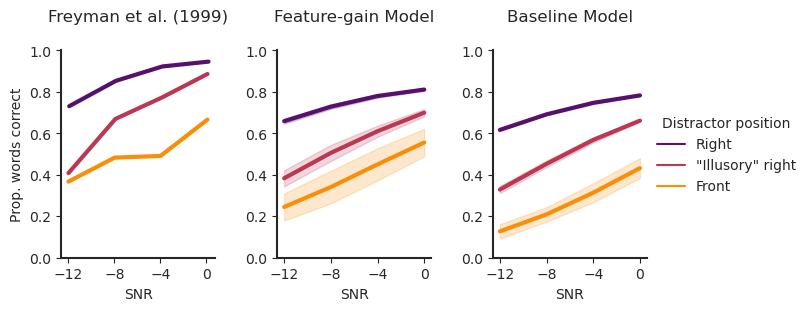

In [55]:
# hue_order = ['F-R', "F-FR", "F-RF", "FR-RF", "FR-FR", 'F-F']
hue_order = ['F-R', "F-RF", 'F-F']

# rename dist_lead_channel names 
name_map = {'F-R':'Right', 'F-FR':'Sim. Front', 'F-RF':'"Illusory" right', 'F-F':'Front', 'FR-RF':'Both simulated, right distractor', 'FR-FR':'Both simulated front'}
hue_order = [name_map[x] for x in hue_order]




sns.set_style('ticks')

models_to_plot = ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout', 'word_task_v09_control_no_attn']

model_name_dict = {'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout' : 'Feature-gain Model', 'word_task_v09_control_no_attn': 'Baseline Model'}

# model_to_plot = freyman_grouped_results[(freyman_grouped_results.model == 'word_task_standard_v07')].copy()
model_to_plot = freyman_grouped_results[freyman_grouped_results.model.isin(models_to_plot)].copy()
model_to_plot.loc[model_to_plot.distractor_azim == 0, "distractor_azim"] = 60
# make dist location be abs 
model_to_plot['distractor_azim'] = model_to_plot['distractor_azim'].abs()

model_to_plot.loc[model_to_plot.snr == 'clean', 'snr'] = 6
model_to_plot = model_to_plot[(model_to_plot.snr.isin([-12, -8, -4, 0])) & (model_to_plot.distractor_azim == 60)]
model_to_plot['model'] = model_to_plot['model'].map(model_name_dict).values
# model_to_plot['model'] = 'Model'

# merge model_to_plot with human data
freyman_human_data['model'] = 'Freyman et al. (1999)'
freyman_human_data['dist_lead_channel'] = freyman_human_data['diotic_cond'] 
freyman_human_data['accuracy_mean'] = freyman_human_data['accuracy']/100

data_to_plot = pd.concat([model_to_plot, freyman_human_data], axis=0)

data_to_plot['dist_lead_channel'] = data_to_plot['dist_lead_channel'].map(name_map)


g = sns.relplot(data=data_to_plot, x='snr', y='accuracy_mean',
             col='model', col_order=['Freyman et al. (1999)'] + list(model_name_dict.values()),
            hue='dist_lead_channel', kind='line',# row='gender_cond',
            palette='inferno',hue_order=hue_order,
            height=3, linewidth=3, aspect=0.75, legend=True,
            facet_kws={'sharey': False, 'sharex': False}
)

g.set(yticks=np.arange(0,  1.1, .20), xticks=np.arange(-12,  1, 4))
# set titles
# g.set_titles("{col_name} {row_name}", size=12, y=1.1)
g.set_titles("{col_name}", size=12, y=1.1)
# set axis labels
g.set_axis_labels("SNR", "Prop. words correct")
# set legend title
g._legend.set_title("Distractor position")
# add w space
g.fig.subplots_adjust(wspace=.4)

# add x and y ticks 


# move legend closer to plot
# g._legend.set_bbox_to_anchor([0.9, 0.5])
# thicken axis lines
for ax in g.axes.flat:
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# don't share y ticks
# plt.tight_layout()
# outfig_dest = Path('ARO_2024/figures')
# plt.tight_layout()
# plt.savefig(outfig_dest/'freyman_plot.svg', transparent=True, bbox_inches='tight')

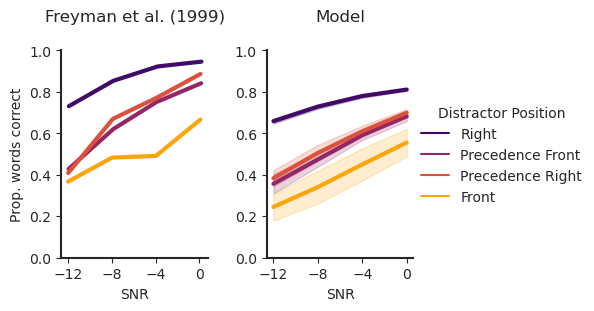

In [58]:
# hue_order = ['F-R', "F-FR", "F-RF", "FR-RF", "FR-FR", 'F-F']
hue_order = ['F-R', "F-FR", "F-RF", 'F-F']

# rename dist_lead_channel names 
name_map = {'F-R':'Right', 'F-FR':'Precedence Front', 'F-RF':'Precedence Right', 'F-F':'Front', 'FR-RF':'Both simulated, right distractor', 'FR-FR':'Both simulated front'}
hue_order = [name_map[x] for x in hue_order]



sns.set_style('ticks')


# model_to_plot = freyman_grouped_results[(freyman_grouped_results.model == 'word_task_half_co_loc_v07')].copy()
model_to_plot = freyman_grouped_results[(freyman_grouped_results.model == 'word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout')].copy()
model_to_plot.loc[model_to_plot.distractor_azim == 0, "distractor_azim"] = 60
# make dist location be abs 
model_to_plot['distractor_azim'] = model_to_plot['distractor_azim'].abs()

model_to_plot.loc[model_to_plot.snr == 'clean', 'snr'] = 6
model_to_plot = model_to_plot[(model_to_plot.snr.isin([-12, -8, -4, 0])) & (model_to_plot.distractor_azim == 60)]
model_to_plot['model'] = 'Model'

# merge model_to_plot with human data
freyman_human_data['model'] = 'Freyman et al. (1999)'
freyman_human_data['dist_lead_channel'] = freyman_human_data['diotic_cond'] 
freyman_human_data['accuracy_mean'] = freyman_human_data['accuracy']/100

data_to_plot = pd.concat([model_to_plot, freyman_human_data], axis=0)

data_to_plot['dist_lead_channel'] = data_to_plot['dist_lead_channel'].map(name_map)


g = sns.relplot(data=data_to_plot, x='snr', y='accuracy_mean',
             col='model', col_order=['Freyman et al. (1999)', 'Model'],
            hue='dist_lead_channel', kind='line',
            palette='inferno',hue_order=hue_order,
            errorbar=('se'),
            height=3, linewidth=3, aspect=0.75, legend=True,
            facet_kws={'sharey': False, 'sharex': False}
)

g.set(yticks=np.arange(0,  1.1, .20), xticks=np.arange(-12,  1, 4))
# set titles
g.set_titles("{col_name}", size=12, y=1.1)
# set axis labels
g.set_axis_labels("SNR", "Prop. words correct")
# set legend title
g._legend.set_title("Distractor Position")
# add w space
g.fig.subplots_adjust(wspace=.4)

# add x and y ticks 


# move legend closer to plot
# g._legend.set_bbox_to_anchor([0.9, 0.5])
# thicken axis lines
for ax in g.axes.flat:
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# don't share y ticks
# plt.tight_layout()
outfig_dest = Path('ARO_2024/figures')
# plt.tight_layout()
# plt.savefig(outfig_dest/'freyman_plot.svg', transparent=True, bbox_inches='tight')

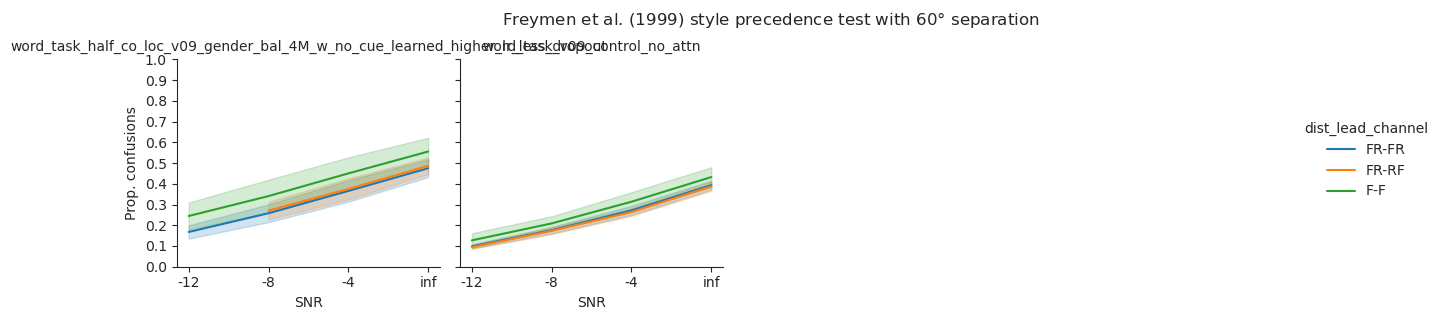

In [60]:

# palette = {'same':'tab:blue', 'diff':'tab:orange'}  

to_plot = freyman_grouped_results.copy()
to_plot.loc[to_plot.snr == 'clean', 'snr'] = 6
to_plot = to_plot[to_plot.snr > -15]

# copy 0 distractor condition to all other azims
to_plot.loc[to_plot.distractor_azim == 0, "distractor_azim"] = -60

# to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')] = to_plot[(to_plot.distractor_azim == 0) & (to_plot.dist_lead_channel == 'F-F')]

# copy 0 distractor condition to all other azims 
# to_plot.loc[(to_plot.distractor_azim != 0) & (to_plot.dist_lead_channel == 'F-F'), 'distractor_azim'] = to_plot.loc[to_plot.distractor_azim == 0, 'target_azim']
g = sns.relplot(data=to_plot[to_plot.distractor_azim == -60],
                #palette=palette,
                x='snr', y='accuracy_mean', errorbar=('se', 1), 
                hue='dist_lead_channel', kind='line', legend=True,
            #    col='distractor_azim',
               col='model',
               col_wrap=4,
                #  palette=palette,
                height=3)
# # iterate through each facet of the facetgrid
# for azim, ax in g.axes_dict.items():
#     # skip the model facet - we bootstrap above 
#     # select the data for the facet
#     data = to_plot[to_plot['target_azim'].eq(azim)]
#     # select the data for each hue group
#     for group, selected in data.groupby('gender_cond'):
#         # plot the errorbar with the correct color for each group 
#         # print(selected)
#         ax.errorbar(data=selected, x="distractor_azim", y="accuracy_mean",
#                      yerr="accuracy_sem", color=palette[group], marker=None, fmt='', ls='none' )

# fix xticks to match azim values
g.set_axis_labels("Distractor azimuth (deg.)", "Prop. accuracy")
g.set_axis_labels("SNR", "Prop. confusions")
g.set_titles("{col_name}")

plt.suptitle("Freymen et al. (1999) style precedence test with 60$\degree$ separation", y=1.05)
# set xticks of g from -90 to 90 
g.set(yticks=np.arange(0,  1.1, 0.1))
# g.legend.remove()

x_tick_locs = np.sort(to_plot.snr.unique())
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) &  (grouped_results.target_azim >= 0)], x='distractor_azim', y='accuracy_mean', hue='gender_cond', kind='line', col='target_azim')